Numba imported
73705


/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]
/home/skelly/school/spices/pytorch_implementation/double_gmm.py:176: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset[f'starlet_{lvl}'] = starlet_cube[e_idx, x_idx, y_idx, lvl]


Cluster 0 Center: x=4099.69, y=4101.65
Cluster 1 Center: x=4101.36, y=4099.20
Cluster 0 Spread (Scaled Units): x_std=0.97, y_std=2.40, theta=335.50
Cluster 1 Spread (Scaled Units): x_std=2.95, y_std=3.13, theta=74.74
Background table should be larger than sources table.
Cluster 0 Center: x=4101.51, y=4099.58
Cluster 1 Center: x=4095.28, y=4099.39
Cluster 2 Center: x=4110.31, y=4099.40
Cluster 3 Center: x=4102.39, y=4098.89
Cluster 0 Spread (Scaled Units): x_std=3.10, y_std=3.11, theta=97.22
Cluster 1 Spread (Scaled Units): x_std=1.93, y_std=2.71, theta=353.85
Cluster 2 Spread (Scaled Units): x_std=1.69, y_std=3.14, theta=358.82
Cluster 3 Spread (Scaled Units): x_std=2.31, y_std=2.76, theta=26.39
Cluster 0 Center: x=4096.01, y=4096.13
Cluster 1 Center: x=4102.77, y=4107.44
Cluster 2 Center: x=4102.55, y=4093.01
Cluster 3 Center: x=4102.60, y=4112.14
Cluster 0 Spread (Scaled Units): x_std=0.56, y_std=1.06, theta=96.23
Cluster 1 Spread (Scaled Units): x_std=1.32, y_std=1.38, theta=354.29


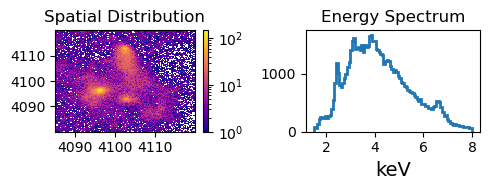

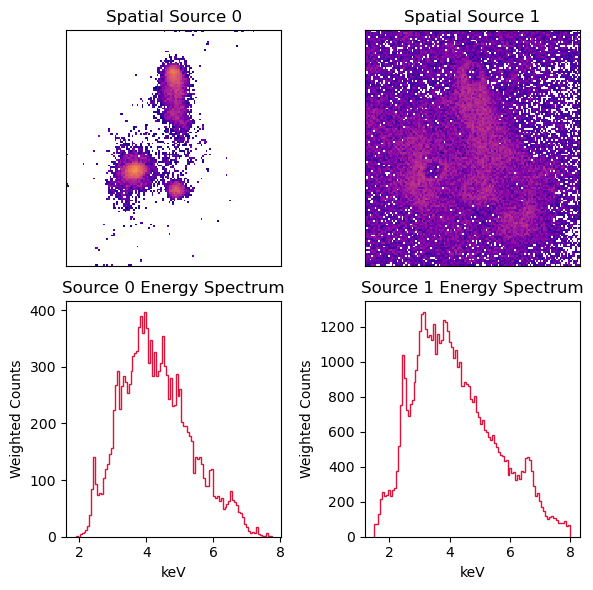

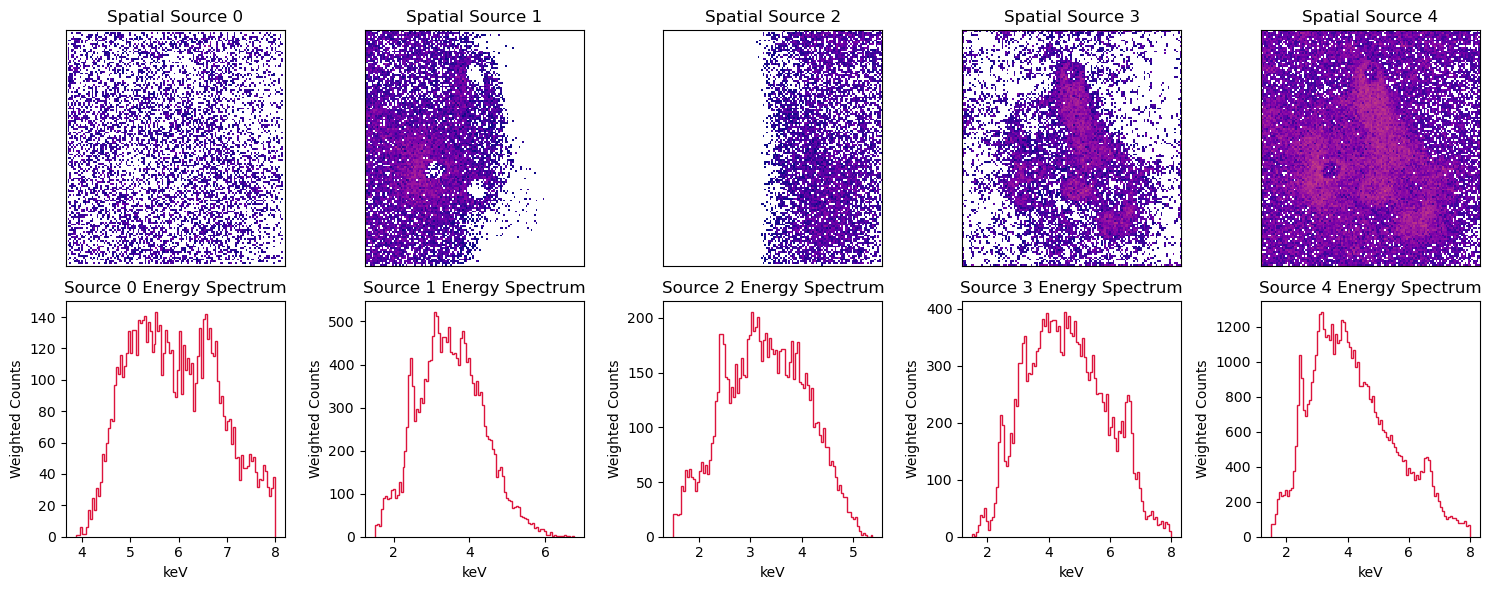

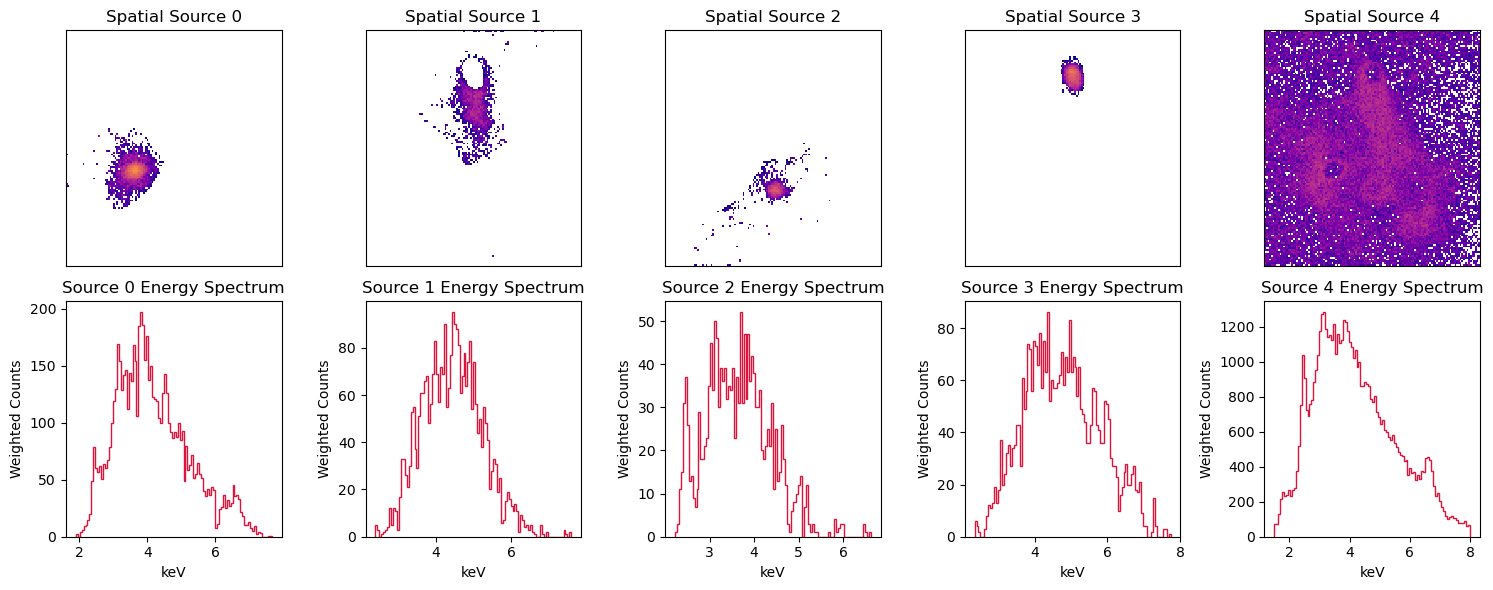

In [1]:
from double_gmm import *

In [12]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def fit_contours_2d(table):
    counts, xedges, yedges = np.histogram2d(
        table['x'], 
        table['y'], 
        bins=[BINX, BINY], 
        weights=table['energy']
    )

    # Calculate bin centers (this is where the data "lives" for the fit)
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)

    # Flatten the grid for curve_fit
    xdata_flat = np.vstack((X.ravel(), Y.ravel()))
    zdata_flat = counts.T.ravel()  # .T to align histogram (x,y) with meshgrid (y,x)

    # 3. Model Functions
    def gaussian(x, y, x0, y0, xalpha, yalpha, A):
        return A * np.exp( -((x-x0)/xalpha)**2 -((y-y0)/yalpha)**2)

    def _gaussian(M, *args):
        x, y = M
        arr = np.zeros(x.shape)
        for i in range(len(args)//5):
            arr += gaussian(x, y, *args[i*5:i*5+5])
        return arr

    # 4. Smart Initial Guesses (Heuristic)
    idx_max = np.argmax(zdata_flat)
    guess_x0 = xdata_flat[0, idx_max]
    guess_y0 = xdata_flat[1, idx_max]
    guess_A = np.max(counts)
    guess_sig = (x_centers.max() - x_centers.min()) / 10

    # Construct p0 for, say, 2 Gaussians (one at peak, one slightly offset)
    p0 = [guess_x0, guess_y0, guess_sig, guess_sig, guess_A,
        guess_x0+1, guess_y0+1, guess_sig, guess_sig, guess_A/2]

    # 5. The Fit
    # Using bounds to keep widths and amplitudes positive
    lower = [-np.inf, -np.inf, 0.1, 0.1, 0] * 2
    upper = [np.inf, np.inf, np.inf, np.inf, np.inf] * 2

    popt, pcov = curve_fit(_gaussian, xdata_flat, zdata_flat, p0=p0, bounds=(lower, upper))

    # 6. Visualization
    fit_grid = _gaussian(xdata_flat, *popt).reshape(BINY, BINX)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Binned Data
    im1 = ax1.imshow(counts.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='plasma')
    ax1.set_title(f'Binned Energy ({BINX}x{BINY})')
    plt.colorbar(im1, ax=ax1)

    # Plot Fit Contours over Data
    ax2.imshow(counts.T, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap='gray_r', alpha=0.5)
    cont = ax2.contour(X, Y, fit_grid, levels=20, cmap='plasma')
    ax2.set_title('Fitted Gaussians (Contours)')
    plt.colorbar(cont, ax=ax2)

    plt.show()

def fit_contours_3d(table):

    # 1. Setup Bins (small for necessity)
    BINX, BINY, BINE = 32, 32, 32

    # 2. Create 3D Histogram (Voxels)
    # This counts how many 'events' fall into each 3D cube
    H, edges = np.histogramdd(
        table[['x', 'y', 'energy']].values, 
        bins=(BINX, BINY, BINE)
    )

    # Calculate bin centers for each axis
    centers = [(e[:-1] + e[1:]) / 2 for e in edges]
    X, Y, E = np.meshgrid(*centers, indexing='ij')

    # Flatten for curve_fit
    # Independent variables: (3, N_voxels)
    coords_flat = np.vstack((X.ravel(), Y.ravel(), E.ravel()))
    # Dependent variable: Density in that voxel
    density_flat = H.ravel()

    # 3. Define 3D Gaussian Model
    def gaussian_3d(coords, x0, y0, e0, sx, sy, se, A):
        x, y, e = coords
        inner = ( (x-x0)/sx )**2 + ( (y-y0)/sy )**2 + ( (e-e0)/se )**2
        return A * np.exp(-inner)

    # 4. Smart Initial Guess
    idx_max = np.argmax(density_flat)
    p0 = [
        coords_flat[0, idx_max], # x0
        coords_flat[1, idx_max], # y0
        coords_flat[2, idx_max], # e0
        np.std(table['x'])/2, # sx
        np.std(table['y'])/2, # sy
        np.std(table['energy'])/2, # se
        np.max(density_flat)     # A
    ]

    # 5. Perform the Fit
    # Constraints: Widths and Amplitude must be positive
    bounds = ([-np.inf, -np.inf, -np.inf, 0.1, 0.1, 0.1, 0], [np.inf]*7)

    popt, _ = curve_fit(gaussian_3d, coords_flat, density_flat, p0=p0, bounds=bounds)

    print("Fitted Center (x, y, energy):", popt[:3])
    print("Fitted Sigmas (sx, sy, se):", popt[3:6])

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot the Raw Data (as a Voxel "Cloud")
    # We only plot bins that have a significant amount of energy to keep it clean
    threshold = np.max(H) * 0.1
    x_idx, y_idx, e_idx = np.where(H > threshold)

    # Convert indices back to actual coordinates for plotting
    sc = ax.scatter(
        X[x_idx, y_idx, e_idx], 
        Y[x_idx, y_idx, e_idx], 
        E[x_idx, y_idx, e_idx], 
        c=H[x_idx, y_idx, e_idx], 
        cmap='viridis', 
        alpha=0.2, 
        s=20,
        label='Binned Data'
    )

    # 2. Plot the Fitted "Blob" Center
    ax.scatter(popt[0], popt[1], popt[2], color='red', s=100, marker='*', label='Fit Center')

    # 3. Plot 3D Error Bars (representing the Sigmas/Spread)
    # This shows the "extent" of the Gaussian in each dimension
    ax.plot([popt[0]-popt[3], popt[0]+popt[3]], [popt[1], popt[1]], [popt[2], popt[2]], color='red', lw=2)
    ax.plot([popt[0], popt[0]], [popt[1]-popt[4], popt[1]+popt[4]], [popt[2], popt[2]], color='red', lw=2)
    ax.plot([popt[0], popt[0]], [popt[1], popt[1]], [popt[2]-popt[5], popt[2]+popt[5]], color='red', lw=2)

    # 4. Optional: Add a "Wireframe" of the Gaussian at 1-Sigma
    # We create a low-res sphere and transform it into the fitted ellipsoid
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    xs = popt[3] * np.cos(u) * np.sin(v) + popt[0]
    ys = popt[4] * np.sin(u) * np.sin(v) + popt[1]
    es = popt[5] * np.cos(v) + popt[2]
    ax.plot_wireframe(xs, ys, es, color="red", alpha=0.5, linewidth=0.5)

    # Labels and styling
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.set_zlabel('Energy')
    ax.set_title('3D Gaussian Blob Fit Visualization')
    plt.colorbar(sc, ax=ax, label='Energy Density', shrink=0.6)
    ax.legend()

    plt.show()

Fitted Center (x, y, energy): [4096.2151259  4096.2229268  4195.31522598]
Fitted Sigmas (sx, sy, se): [1.25765459e+00 1.10790193e+00 1.85406397e+03]


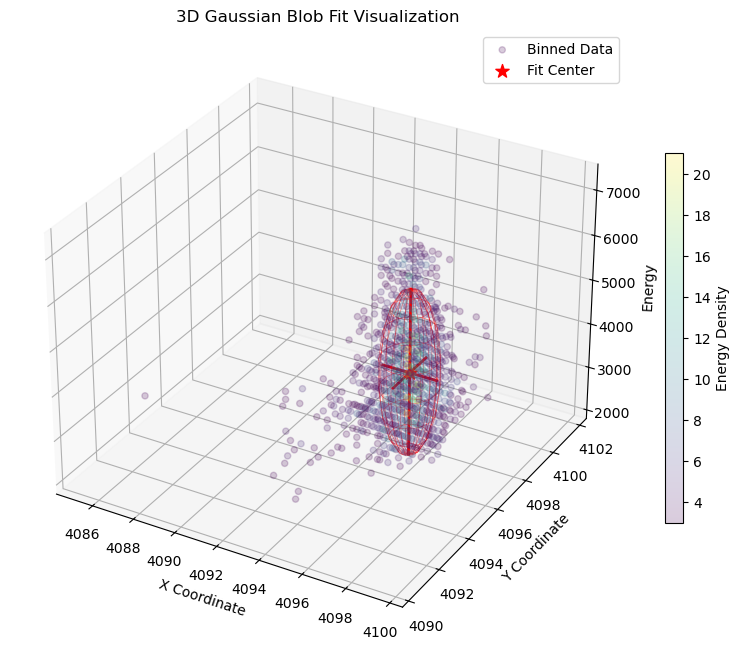

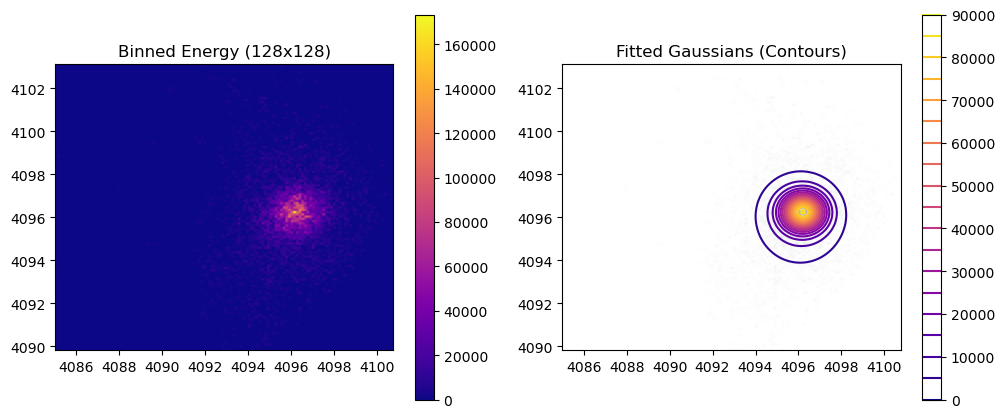

Fitted Center (x, y, energy): [4102.84967062 4107.38827425 4439.91184265]
Fitted Sigmas (sx, sy, se): [   1.90969918    3.83158975 1196.86169649]


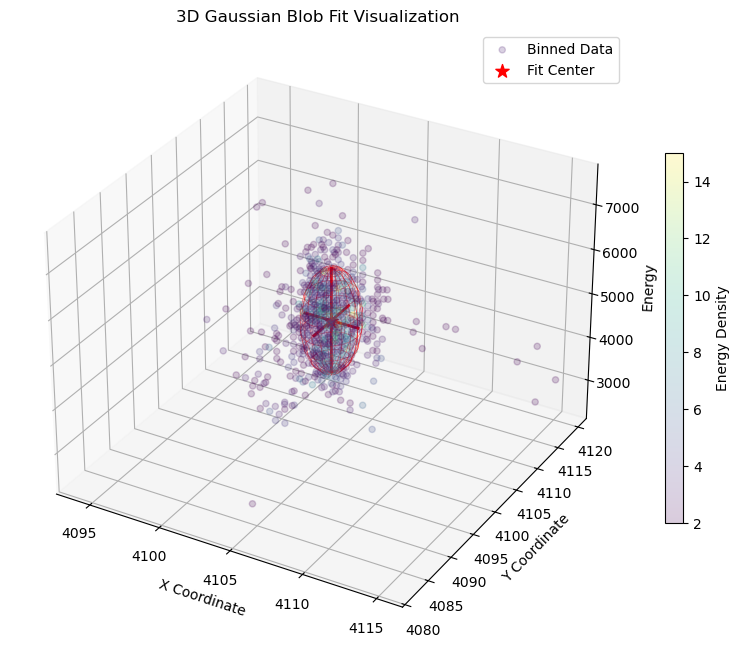

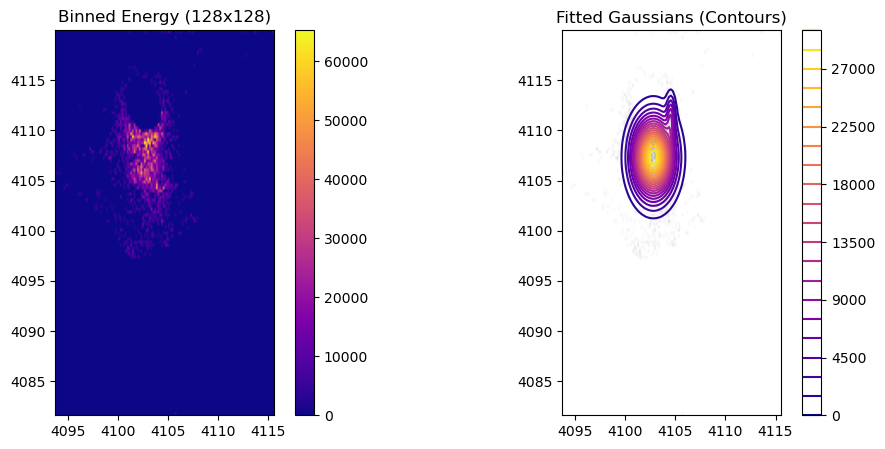

Fitted Center (x, y, energy): [4102.90685766 4092.92730348 3471.16007135]
Fitted Sigmas (sx, sy, se): [1.08396300e+00 1.00728888e+00 1.29263369e+03]


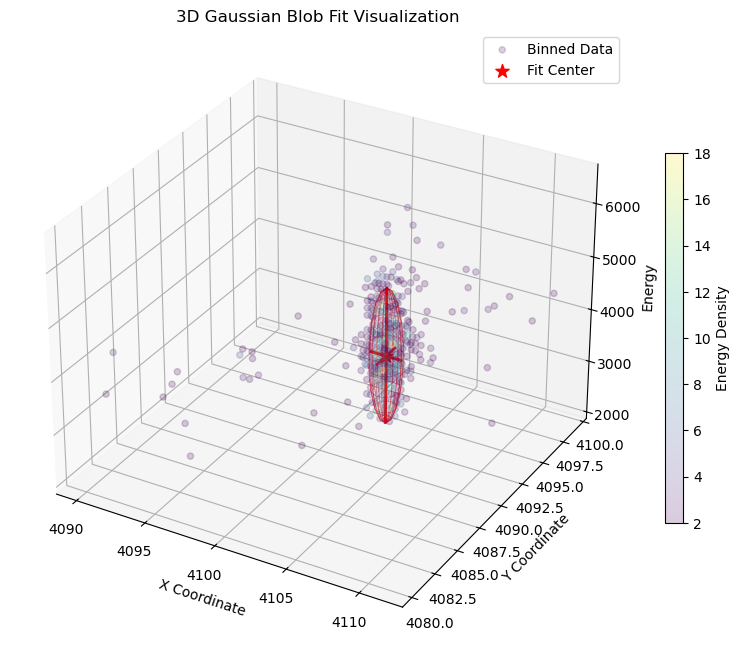

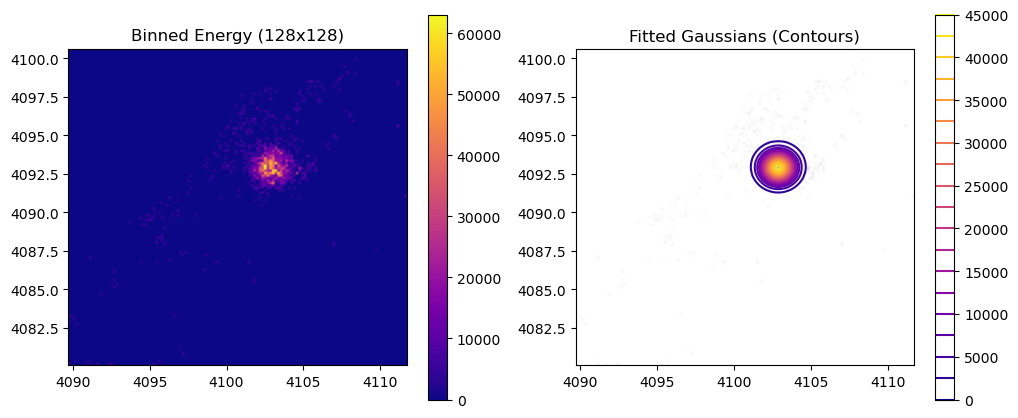

Fitted Center (x, y, energy): [4102.56371565 4112.3961831  4650.30147754]
Fitted Sigmas (sx, sy, se): [1.05870225e+00 1.58436773e+00 1.65788292e+03]


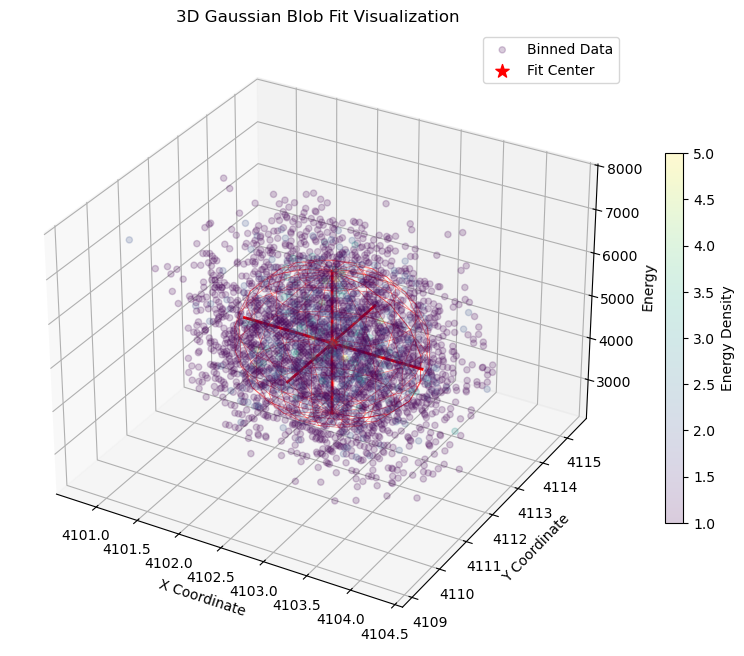

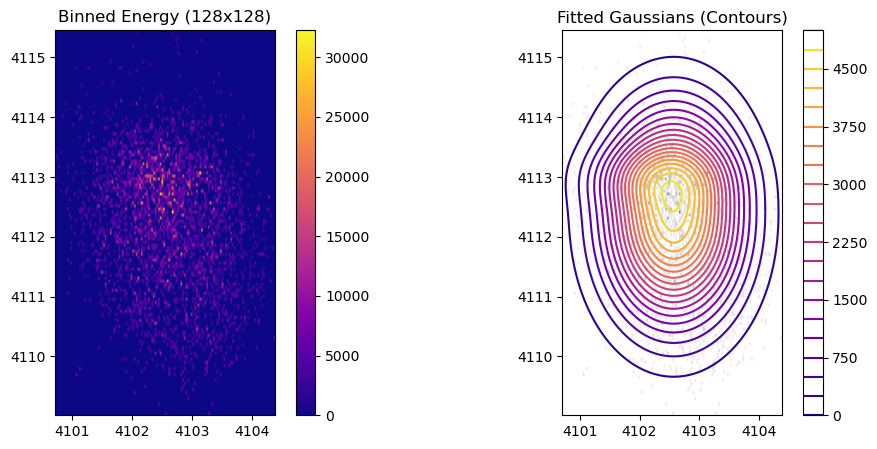

Fitted Center (x, y, energy): [4100.57259953 4097.957042   3920.73287838]
Fitted Sigmas (sx, sy, se): [  16.49101093   19.31748343 2031.55444202]


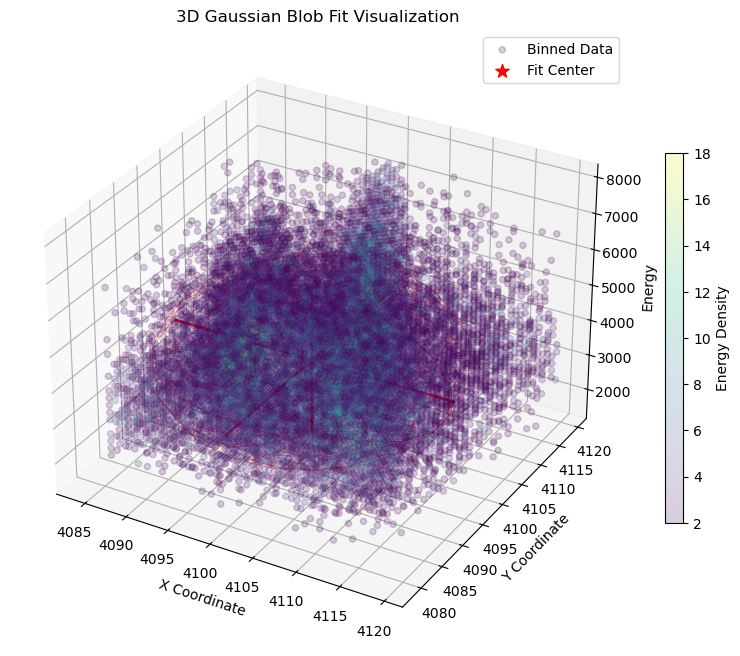

RuntimeError: Optimal parameters not found: The maximum number of function evaluations is exceeded.

In [ ]:
for source in [*split_sources,table_bg]:
    fit_contours_3d(source)
    fit_contours_2d(source) # NOTE: 2d contour fitting does not work for the background for some reason

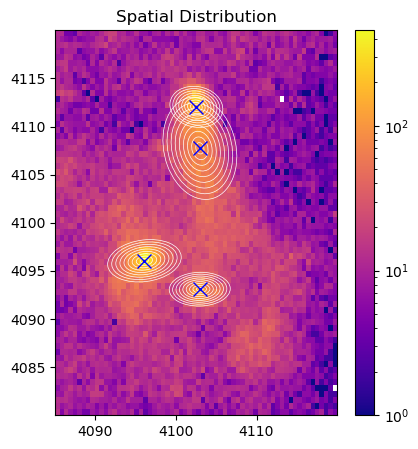

In [4]:
from matplotlib.patches import Ellipse
fig = plt.figure(figsize=(10, 5)) 
ax1 = fig.add_subplot(1, 2, 1)
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution')
fig.colorbar(h2d[3], ax=ax1)

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice]

    ax1.plot(src_center[0], src_center[1], 'bx', markersize=10, label='Center')
    for i in range(10):
        ellipse = Ellipse(xy=src_center, width=src_std_dev[0] * i, height=src_std_dev[1] * i,
                                angle = src_std_dev[2], edgecolor='w', fc='None', lw=0.5)
        ax1.add_patch(ellipse)


In [5]:
def generate_elliptical_profile(df, center, widths, angle_deg, num_bins=10):
    # 1. Setup coordinates relative to center
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    
    # 2. Rotate coordinates to align with ellipse axes
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # 3. Calculate "Elliptical Radius" 
    # This radius = 1.0 at the boundary of the ellipse defined by 'widths'
    # width/2 and height/2 represent the semi-axes (1-sigma)
    r_ell = np.sqrt((x_rot / (widths[0]))**2 + (y_rot / (widths[1]))**2)
    
    # 4. Binning
    # We'll use the 'i' from your loop as the bin index
    df['ell_bin'] = np.digitize(r_ell, bins=np.arange(num_bins + 1))
    
    # 5. Aggregate Energy
    df['weighted_energy'] = df['energy'] * df['weight']
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    return profile

In [142]:
def generate_normalized_profile(df, center, widths, angle_deg, num_bins=10, prec=5.0):
    # --- 1. Calculate the Elliptical Radius ---
    dx = df['x'] - center[0]
    dy = df['y'] - center[1]
    theta = np.radians(-angle_deg)
    x_rot = dx * np.cos(theta) - dy * np.sin(theta)
    y_rot = dx * np.sin(theta) + dy * np.cos(theta)
    
    # Radii normalized to the prec-sigma widths 
    # (so when we go num_bins sigma out, we're acutally going num_bins / prec sigma out)
    r_ell = np.sqrt((x_rot / widths[0])**2 + (y_rot / widths[1])**2) * prec

    # --- 2. Binning ---
    bins = np.arange(num_bins + 1)
    df['ell_bin'] = np.digitize(r_ell, bins=bins)
    
    # --- 3. Aggregate Energy ---
    df['weighted_energy'] = df['energy']
    if 'weight' in df.columns:
        df['weighted_energy'] *= df['weight']
    
    profile = df.groupby('ell_bin')['weighted_energy'].sum().reset_index()
    
    # --- 4. Calculate Area of each Elliptical Annulus ---
    # Area of ellipse i: Pi * (a * i) * (b * i) = Pi * a * b * i^2
    def get_area(sigma_level):
        return np.pi * widths[0] * widths[1] * (sigma_level**2)

    areas = []
    for b in profile['ell_bin']:
        area_outer = get_area(b)
        area_inner = get_area(b - 1)
        areas.append(area_outer - area_inner)
    
    profile['area'] = areas
    profile['energy_density'] = profile['weighted_energy'] / profile['area']
    
    return profile

/tmp/ipykernel_23635/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ell_bin'] = np.digitize(r_ell, bins=bins)
/tmp/ipykernel_23635/4287771349.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['weighted_energy'] = df['energy']
/tmp/ipykernel_23635/4287771349.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

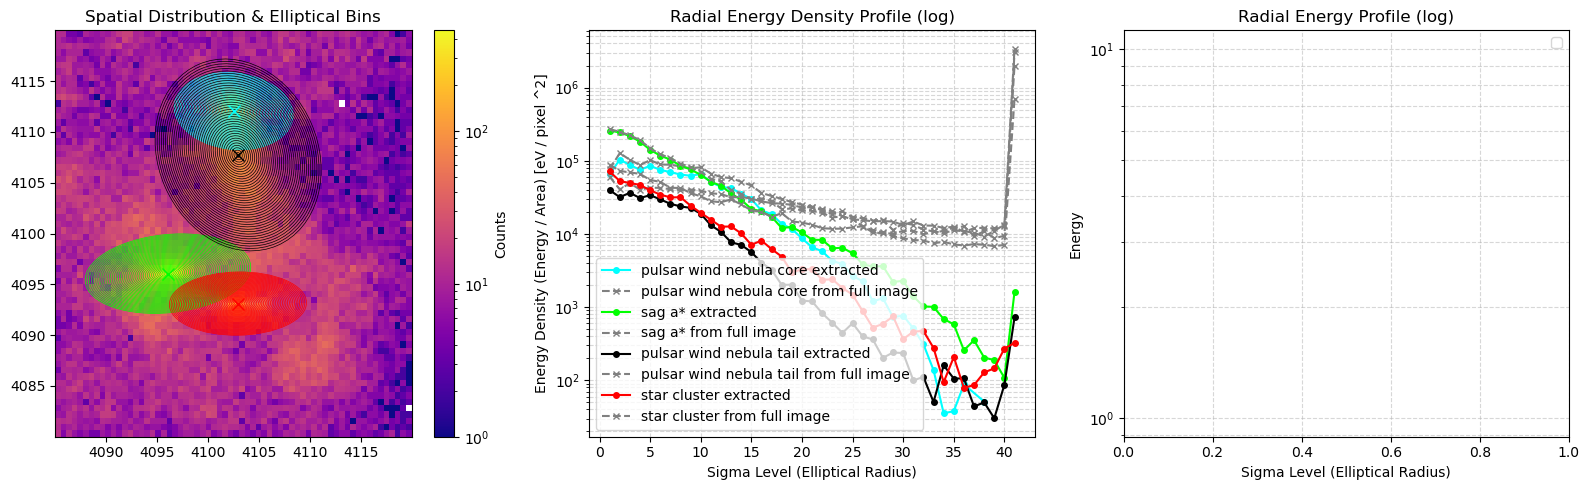

In [144]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse

# Setup the figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# 1. Plot the background 2D Histogram on ax1
h2d = ax1.hist2d(subset['x'], subset['y'], bins=(BINX, BINY), 
                 cmap='plasma', norm=LogNorm())
ax1.set_title('Spatial Distribution & Elliptical Bins')
fig.colorbar(h2d[3], ax=ax1, label='Counts')

# Define a color palette for the 4 sources
colors = ['cyan', 'lime', 'black', 'red']
source_names = ['pulsar wind nebula core', 'sag a*', 'pulsar wind nebula tail', 'star cluster']

for choice in range(4):
    src = split_sources[choice]
    src_center = centers[choice]
    src_std_dev = std_dev[choice] # [std_x, std_y, angle]
    color = colors[choice]

    # --- Generate the Normalized Profile ---
    prec = 5.0
    num_bins = 40
    profile = generate_normalized_profile(src, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    profile_base = generate_normalized_profile(subset, src_center, src_std_dev[:2], src_std_dev[2], num_bins=num_bins, prec=prec)
    
    ax1.plot(src_center[0], src_center[1], marker='x', color=color, markersize=8)
    
    for i in range(1, num_bins + 1):
        ellipse = Ellipse(xy=src_center, 
                          width=src_std_dev[0] * 2 * i / prec, 
                          height=src_std_dev[1] * 2 * i / prec,
                          angle=src_std_dev[2], 
                          edgecolor=color, fc='None', lw=0.5)
        ax1.add_patch(ellipse)

    ax2.plot(profile['ell_bin'], profile['energy_density'], 
             marker='o', markersize=4, linestyle='-', 
             color=color, label=f'{source_names[choice]} extracted')
    ax2.plot(profile_base['ell_bin'], profile_base['energy_density'], 
             marker='x', markersize=4, linestyle='--', 
             color='gray', label=f'{source_names[choice]} from full image')

# Final formatting for the Profile Plot
ax2.set_title('Radial Energy Density Profile (log)')
ax2.set_xlabel('Sigma Level (Elliptical Radius)')
ax2.set_ylabel('Energy Density (Energy / Area) [eV / pixel ^2]')
ax2.set_yscale('log')
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend()
ax3.set_title('Radial Energy Profile (log)')
ax3.set_xlabel('Sigma Level (Elliptical Radius)')
ax3.set_yscale('log')
ax3.set_ylabel('Energy')
ax3.grid(True, which="both", linestyle='--', alpha=0.5)
ax3.legend()

plt.tight_layout()
plt.show()